In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

market = pd.read_csv("../data/market_master.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

In [2]:
market["ma_20"] = market["nifty_close"].rolling(20).mean()
market["ma_50"] = market["nifty_close"].rolling(50).mean()

# Trend strength
market["trend_signal"] = (market["ma_20"] - market["ma_50"]) / market["nifty_close"]

# Trend slope (normalized)
market["trend_slope"] = market["ma_20"].diff(5) / market["nifty_close"]

In [3]:
# Decision layer
market["trend_direction"] = np.where(
    market["trend_signal"] > 0, 1,
    np.where(market["trend_signal"] < 0, -1, 0)
)


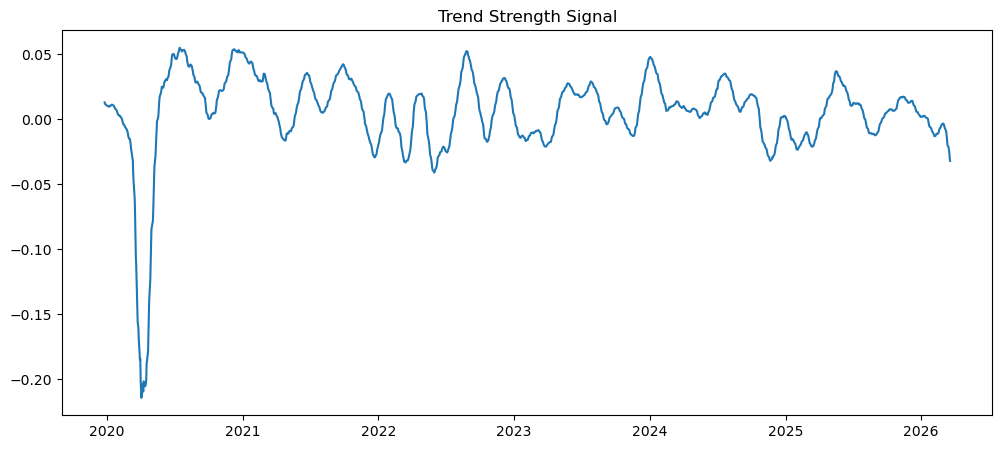

In [6]:
# Visualization 
plt.figure(figsize=(12,5))
plt.plot(market.index, market["trend_signal"])
plt.title("Trend Strength Signal")
plt.show()

In [5]:
market = market.dropna()

market.to_csv("../data/market_master.csv")